# Contextual Overlay and Proximity Analysis
Four overlay maps, one per method:
- **HDBSCAN** min\_cluster\_size = 20 — top 10 clusters by size
- **DBSCAN** ε = 200 m — top 10 clusters by size
- **KDE** h = 360 m, 95th percentile threshold
- **Percolation** coalescence map (all four stages)

Followed by proximity analysis (mound distance to nearest temple and hydrology
boundary) for all four methods.

In [27]:
import numpy as np
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import hdbscan
import networkx as nx
from sklearn.cluster import DBSCAN
from sklearn.neighbors import KernelDensity
from scipy.spatial import cKDTree
from scipy.signal import savgol_filter
import warnings
warnings.filterwarnings('ignore')

OUT = '/Users/amber/Documents/M Thesis/Notebooks/Evaluation/'

# ── Colour palette ───────────────────────────────────────────────────────
COL_HYDRO_FILL = '#B3DEF5'
COL_HYDRO_EDGE = '#2979FF'
COL_TEMPLE     = '#C62828'
COL_NOISE      = '#BDBDBD'   # noise / background mounds
COL_OTHER_CL   = '#90A4AE'   # minor clusters — blue-grey tint

# Top-10 cluster palette: warm and varied, readable on pale-blue hydrology
PAL_10 = [
    '#E91E8C',  # vivid pink
    '#1565C0',  # dark blue
    '#1B5E20',  # dark green
    '#7B1FA2',  # purple
    '#F57F17',  # amber
    '#00695C',  # dark teal
    '#558B2F',  # olive green
    '#4527A0',  # indigo
    '#00838F',  # cyan
    '#827717',  # dark khaki
]

STAGE_COL  = {1:'#0D2951', 2:'#1B5E20', 3:'#E65100', 4:'#546E7A', 5:'#9E9E9E'}
STAGE_NAME = {1:'Sub-critical', 2:'Critical', 3:'Supra-critical',
              4:'Merged', 5:'Outlier'}

def plot_temples(ax, zorder=6):
    '''White halo outline + red fill for maximum contrast.'''
    temples.plot(ax=ax, facecolor='none', edgecolor='white',
                 linewidth=3.5, alpha=1.0, zorder=zorder)
    temples.plot(ax=ax, facecolor=COL_TEMPLE, edgecolor='#7B0000',
                 linewidth=0.8, alpha=0.92, zorder=zorder + 1)

print('Imports OK')

Imports OK


## 1. Load Data

In [2]:
features  = gpd.read_file('/Users/amber/Documents/M Thesis/Data/QGIS/isaura_features.gpkg')
parcel    = gpd.read_file('/Users/amber/Documents/M Thesis/Data/QGIS/08_isaura_extent.shp')

mounds    = features[features['type'] == 'mound'].copy()
temples   = features[features['type'] == 'temple'].copy()
hydrology = features[features['type'] == 'hydrology'].copy()

centroids = mounds.geometry.centroid
x = centroids.x.values
y = centroids.y.values
coords = np.column_stack([x, y])
N = len(coords)

tx = temples.geometry.centroid.x.values
ty = temples.geometry.centroid.y.values

print(f'Mounds:    {N:,}')
print(f'Temples:   {len(temples):,}')
print(f'Hydrology: {len(hydrology):,}')

Mounds:    2,671
Temples:   192
Hydrology: 3,911


## 2. Compute Clustering Assignments

In [3]:
# HDBSCAN mc=20
cl_hdb = hdbscan.HDBSCAN(min_cluster_size=20, min_samples=4, metric='euclidean',
                          cluster_selection_method='eom', prediction_data=True)
cl_hdb.fit(coords)
hdb_labels = cl_hdb.labels_
n_cl_hdb   = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
n_no_hdb   = (hdb_labels == -1).sum()
print(f'HDBSCAN mc=20: {n_cl_hdb} clusters, {n_no_hdb:,} noise ({100*n_no_hdb/N:.1f}%)')

HDBSCAN mc=20: 28 clusters, 1,251 noise (46.8%)


In [4]:
# DBSCAN eps=200 m
db = DBSCAN(eps=200, min_samples=4, algorithm='ball_tree', metric='euclidean').fit(coords)
db_labels  = db.labels_
n_cl_db    = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_no_db    = (db_labels == -1).sum()
print(f'DBSCAN eps=200m: {n_cl_db} clusters, {n_no_db:,} noise ({100*n_no_db/N:.1f}%)')

DBSCAN eps=200m: 97 clusters, 749 noise (28.0%)


In [12]:
# KDE - bandwidth 360 m, 90th percentile threshold
xg = np.linspace(x.min(), x.max(), 300)
yg = np.linspace(y.min(), y.max(), 300)
XX, YY   = np.meshgrid(xg, yg)
grid_pts = np.column_stack([XX.ravel(), YY.ravel()])

kde_model = KernelDensity(bandwidth=360, kernel='gaussian',
                           algorithm='ball_tree').fit(coords)
log_dens  = kde_model.score_samples(grid_pts)
dens_grid = np.exp(log_dens).reshape(XX.shape)

grid_kd    = cKDTree(grid_pts)
_, idx     = grid_kd.query(coords, k=1)
mound_dens = dens_grid.ravel()[idx]

threshold_90 = np.percentile(dens_grid, 90)
kde_inzone   = mound_dens >= threshold_90
print(f'KDE threshold (p90): {threshold_90:.6e}')
print(f'In-zone mounds: {kde_inzone.sum():,} ({100*kde_inzone.mean():.1f}%)')

KDE threshold (p90): 8.211595e-09
In-zone mounds: 1,410 (52.8%)


In [6]:
# Percolation - coalescence stages
R_VALS  = np.logspace(np.log10(50), np.log10(3000), 200)
kd_tree = cKDTree(coords)
S_vals  = []
for r in R_VALS:
    pairs = list(kd_tree.query_pairs(r))
    G = nx.Graph(); G.add_nodes_from(range(N)); G.add_edges_from(pairs)
    comps = list(nx.connected_components(G))
    S_vals.append(max(len(c) for c in comps) / N if comps else 0)

S_sm   = savgol_filter(np.array(S_vals), window_length=11, polyorder=3)
rc_idx = np.argmax(np.gradient(S_sm, R_VALS))
r_c    = R_VALS[rc_idx]
print(f'Critical radius r_c = {r_c:.0f} m')

def giant_at(r):
    pairs = list(kd_tree.query_pairs(r))
    G = nx.Graph(); G.add_nodes_from(range(N)); G.add_edges_from(pairs)
    comps = sorted(nx.connected_components(G), key=len, reverse=True)
    return set(comps[0]) if comps else set()

giant_sub   = giant_at(R_VALS[np.searchsorted(R_VALS, 132)])
giant_crit  = giant_at(r_c)
giant_supra = giant_at(R_VALS[np.searchsorted(R_VALS, 641)])
giant_merge = giant_at(R_VALS[np.searchsorted(R_VALS, 1291)])

stage = np.full(N, 5, dtype=int)
for i in range(N):
    if i in giant_merge: stage[i] = 4
    if i in giant_supra: stage[i] = 3
    if i in giant_crit:  stage[i] = 2
    if i in giant_sub:   stage[i] = 1

counts = {s: int((stage == s).sum()) for s in range(1, 6)}
for s, n in counts.items():
    print(f'  Stage {s} ({STAGE_NAME[s]}): {n:,} mounds ({100*n/N:.1f}%)')

Critical radius r_c = 325 m
  Stage 1 (Sub-critical): 368 mounds (13.8%)
  Stage 2 (Critical): 1,641 mounds (61.4%)
  Stage 3 (Supra-critical): 626 mounds (23.4%)
  Stage 4 (Merged): 35 mounds (1.3%)
  Stage 5 (Outlier): 1 mounds (0.0%)


## 3. Overlay Maps

Temples (red, white halo) and hydrology (pale blue fill) overlaid on each clustering output.
Top 10 clusters by mound count shown in distinct colours; remaining clusters in light grey;
noise mounds in mid-grey. 

In [7]:
def plot_top10_map(ax, labels, title):
    '''Top-10 clusters by size, with temple and hydrology overlay.'''
    noise_mask  = labels == -1
    cluster_ids = sorted(set(labels[~noise_mask]))
    cl_sizes    = sorted([(cl_id, int((labels==cl_id).sum()))
                           for cl_id in cluster_ids],
                         key=lambda t: t[1], reverse=True)
    top10   = [cl_id for cl_id, _ in cl_sizes[:10]]
    others  = [cl_id for cl_id, _ in cl_sizes[10:]]
    n_no    = int(noise_mask.sum())
    n_other = int(sum(s for _, s in cl_sizes[10:]))

    # 1. Hydrology background
    hydrology.plot(ax=ax, facecolor=COL_HYDRO_FILL, edgecolor=COL_HYDRO_EDGE,
                  linewidth=0.5, alpha=0.45, zorder=1)
    # 2. Noise
    ax.scatter(x[noise_mask], y[noise_mask], s=2, c=COL_NOISE, alpha=0.55, zorder=2)
    # 3. Minor clusters (grey)
    if others:
        other_mask = np.isin(labels, others)
        ax.scatter(x[other_mask], y[other_mask], s=3.5, c=COL_OTHER_CL, alpha=0.65, zorder=3)
    # 4. Top-10
    for rank, cl_id in enumerate(top10):
        mask = labels == cl_id
        sz   = cl_sizes[rank][1]
        ax.scatter(x[mask], y[mask], s=6, color=PAL_10[rank],
                   alpha=0.90, zorder=4, label=f'Cluster {rank+1} (n={sz:,})')
    # 5. Temples
    plot_temples(ax, zorder=5)
    # 6. Parcel boundary
    parcel.boundary.plot(ax=ax, color='black', linewidth=1.0, zorder=7)

    # Legend
    handles = [ax.get_legend_handles_labels()[0][i] for i in range(len(top10))]
    if n_other > 0:
        handles.append(mpatches.Patch(facecolor=COL_OTHER_CL,
                                      label=f'Other clusters (n={n_other:,})'))
    handles.append(mpatches.Patch(facecolor=COL_NOISE, alpha=0.8,
                                   label=f'Noise (n={n_no:,})'))
    handles.append(mpatches.Patch(facecolor=COL_TEMPLE, edgecolor='white', linewidth=1.5,
                                   label=f'Temples (n={len(temples):,})'))
    handles.append(mpatches.Patch(facecolor=COL_HYDRO_FILL, edgecolor=COL_HYDRO_EDGE,
                                   linewidth=1, label=f'Hydrology (n={len(hydrology):,})'))
    ax.legend(handles=handles, loc='upper left', fontsize=7.5,
              framealpha=0.92, ncol=1)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=11, pad=8)
    ax.set_xlabel('X (m)', fontsize=9)
    ax.set_ylabel('Y (m)', fontsize=9)
    ax.tick_params(labelsize=7)
    return cl_sizes

print('Helper defined.')

Helper defined.


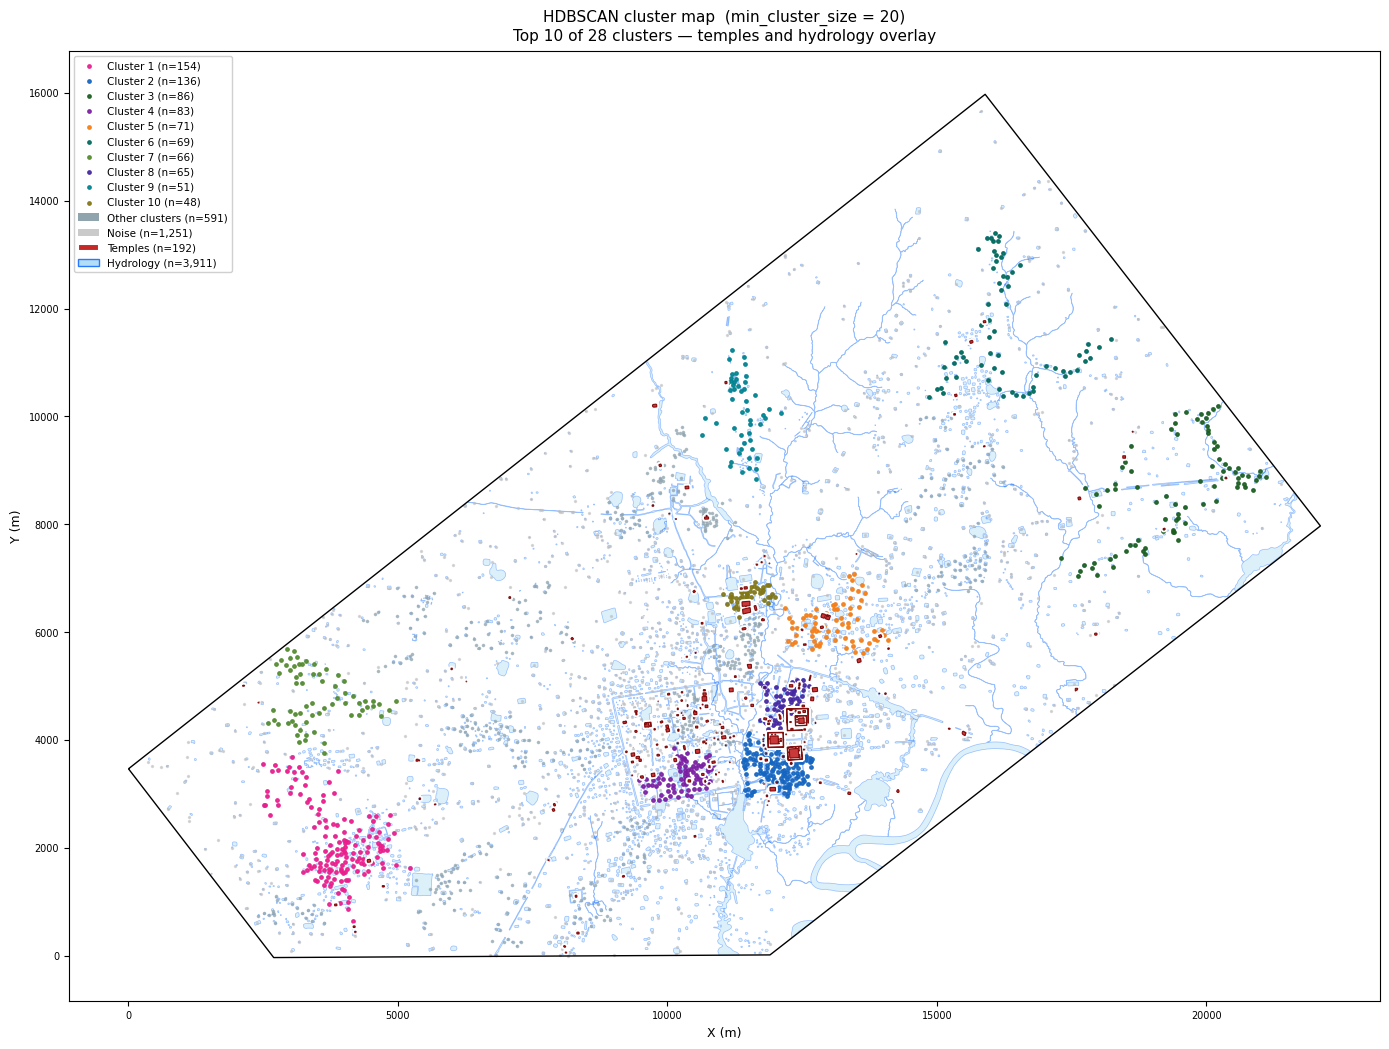

Saved: overlay_hdbscan_mc20.png
Top-10 cluster sizes:
  Rank 1: cluster 11, n=154
  Rank 2: cluster 24, n=136
  Rank 3: cluster 0, n=86
  Rank 4: cluster 26, n=83
  Rank 5: cluster 19, n=71
  Rank 6: cluster 3, n=69
  Rank 7: cluster 9, n=66
  Rank 8: cluster 21, n=65
  Rank 9: cluster 6, n=51
  Rank 10: cluster 20, n=48


In [28]:
# HDBSCAN mc=20
fig, ax = plt.subplots(figsize=(14, 12))
sizes_hdb = plot_top10_map(
    ax, hdb_labels,
    f'HDBSCAN cluster map  (min_cluster_size = 20)\n'
    f'Top 10 of {len(set(hdb_labels))-(1 if -1 in hdb_labels else 0)} clusters — '
    f'temples and hydrology overlay'
)
plt.tight_layout()
plt.savefig(OUT + 'overlay_hdbscan_mc20.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: overlay_hdbscan_mc20.png')
print('Top-10 cluster sizes:')
for rank, (cl_id, sz) in enumerate(sizes_hdb[:10], 1):
    print(f'  Rank {rank}: cluster {cl_id}, n={sz:,}')

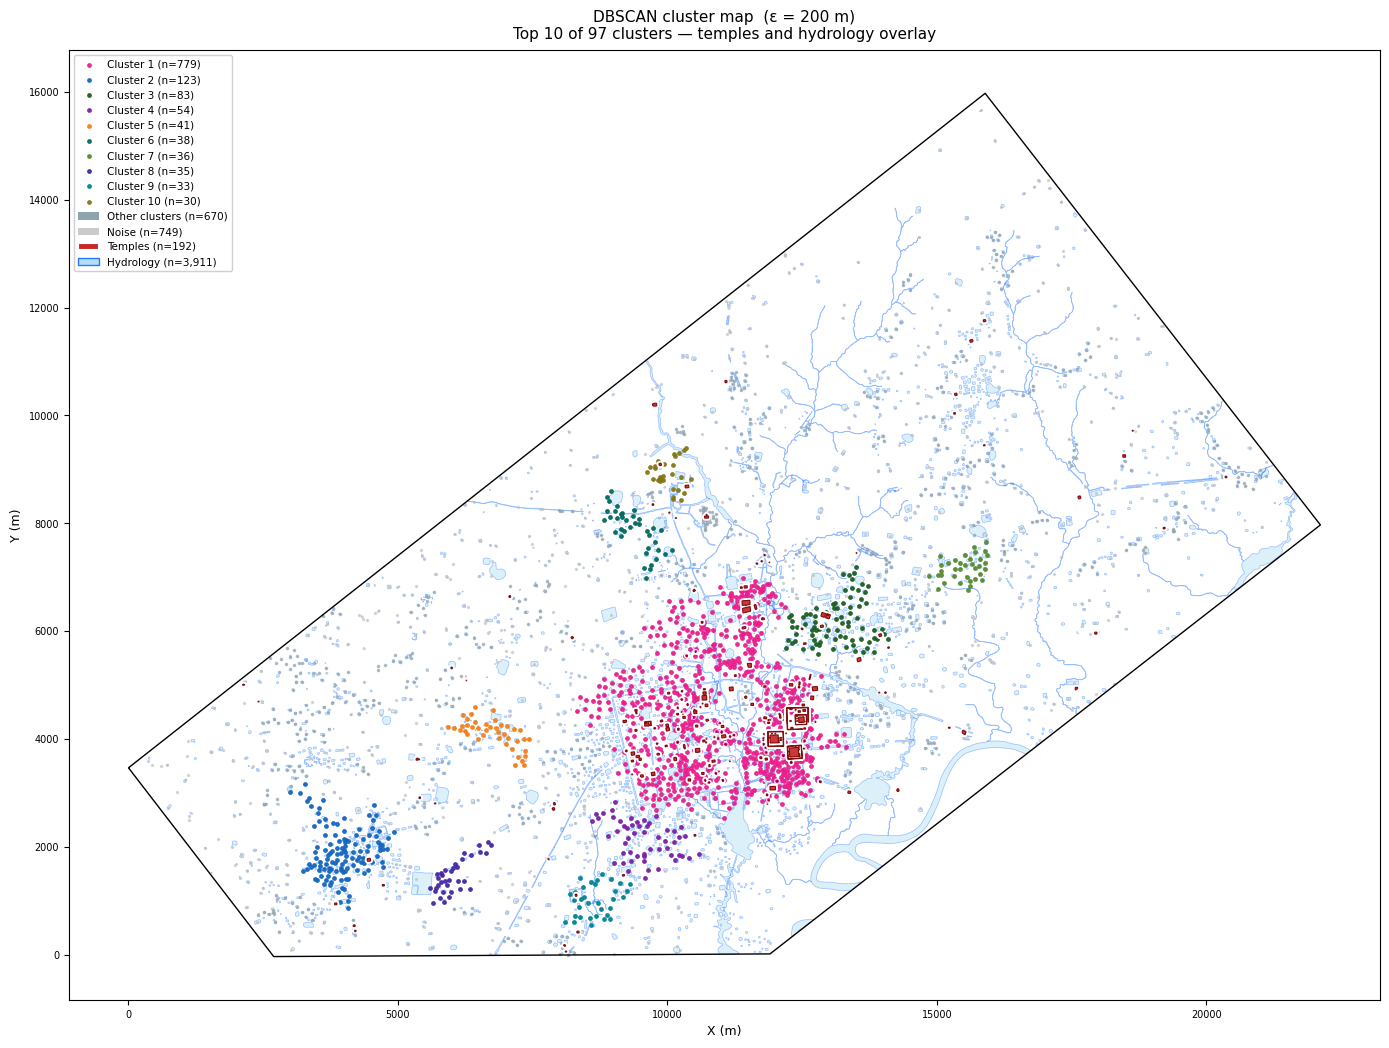

Saved: overlay_dbscan_eps200.png
Top-10 cluster sizes:
  Rank 1: cluster 2, n=779
  Rank 2: cluster 4, n=123
  Rank 3: cluster 11, n=83
  Rank 4: cluster 22, n=54
  Rank 5: cluster 16, n=41
  Rank 6: cluster 17, n=38
  Rank 7: cluster 27, n=36
  Rank 8: cluster 59, n=35
  Rank 9: cluster 60, n=33
  Rank 10: cluster 65, n=30


In [29]:
# DBSCAN eps=200m
fig, ax = plt.subplots(figsize=(14, 12))
sizes_db = plot_top10_map(
    ax, db_labels,
    f'DBSCAN cluster map  (ε = 200 m)\n'
    f'Top 10 of {len(set(db_labels))-(1 if -1 in db_labels else 0)} clusters — '
    f'temples and hydrology overlay'
)
plt.tight_layout()
plt.savefig(OUT + 'overlay_dbscan_eps200.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: overlay_dbscan_eps200.png')
print('Top-10 cluster sizes:')
for rank, (cl_id, sz) in enumerate(sizes_db[:10], 1):
    print(f'  Rank {rank}: cluster {cl_id}, n={sz:,}')

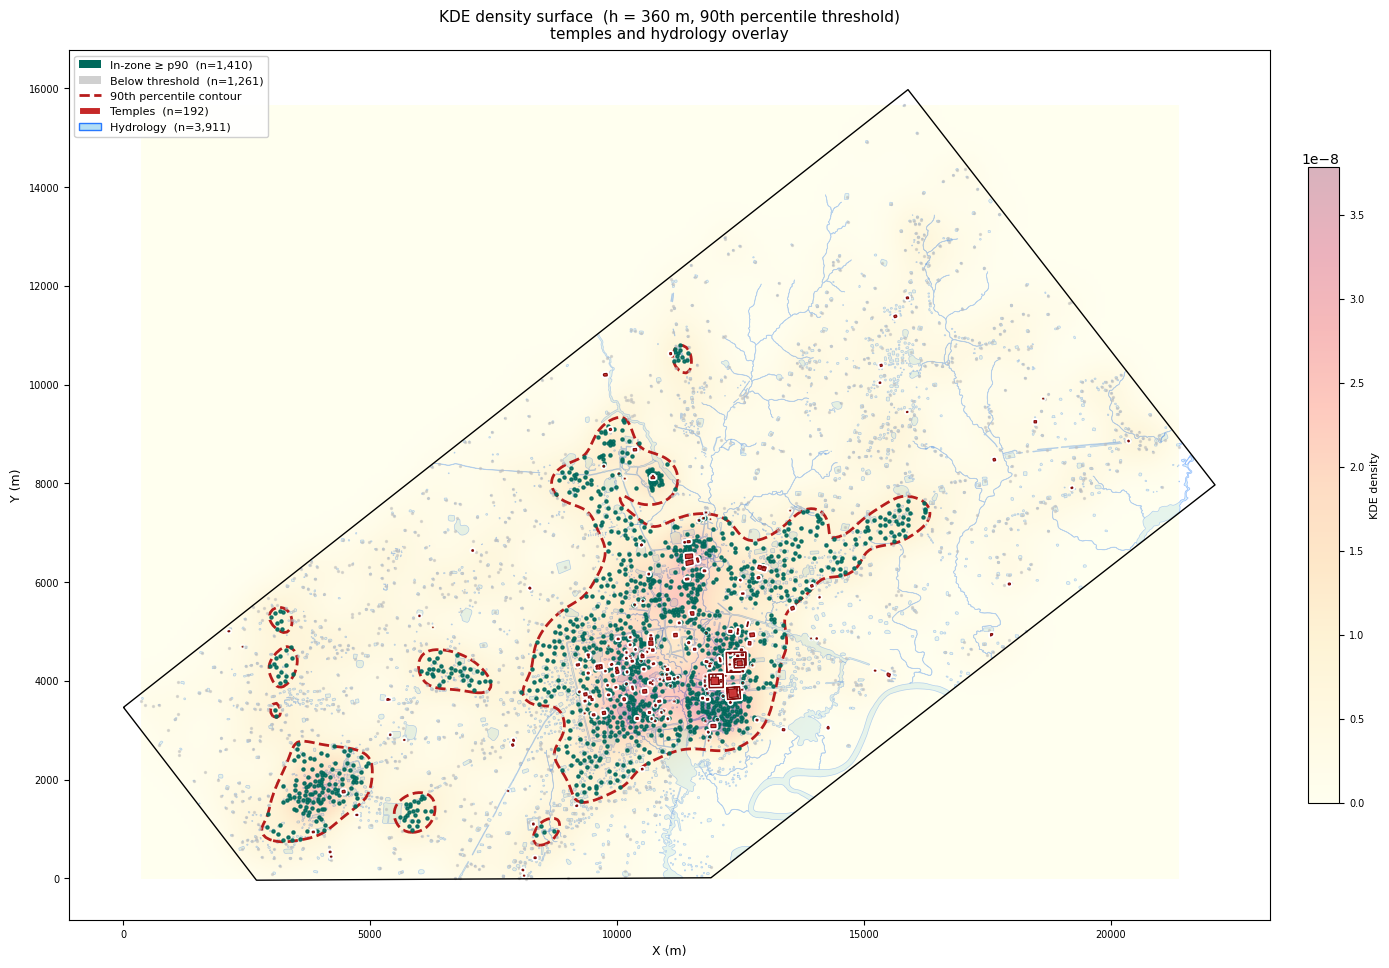

Saved: overlay_kde_h360_p90.png


In [31]:
# KDE h=360m, 90th percentile
fig, ax = plt.subplots(figsize=(14, 12))

hydrology.plot(ax=ax, facecolor=COL_HYDRO_FILL, edgecolor=COL_HYDRO_EDGE,
               linewidth=0.5, alpha=0.45, zorder=1)

ext = [xg.min(), xg.max(), yg.min(), yg.max()]
im  = ax.imshow(dens_grid, origin='lower', extent=ext,
                cmap='YlOrRd', alpha=0.30, zorder=2, aspect='equal')

ax.contour(XX, YY, dens_grid, levels=[threshold_90],
           colors='#B71C1C', linewidths=2.0, linestyles='--', zorder=3)

kde_out = ~kde_inzone
ax.scatter(x[kde_out], y[kde_out], s=2, c=COL_NOISE, alpha=0.50, zorder=4)
ax.scatter(x[kde_inzone], y[kde_inzone], s=5, c='#00695C', alpha=0.88, zorder=5)

plot_temples(ax, zorder=6)
parcel.boundary.plot(ax=ax, color='black', linewidth=1.0, zorder=8)

cbar = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.03)
cbar.set_label('KDE density', fontsize=8)
cbar.ax.tick_params(labelsize=7)

legend_handles = [
    mpatches.Patch(facecolor='#00695C',
                   label=f'In-zone ≥ p90  (n={kde_inzone.sum():,})'),
    mpatches.Patch(facecolor=COL_NOISE, alpha=0.7,
                   label=f'Below threshold  (n={kde_out.sum():,})'),
    Line2D([0],[0], color='#B71C1C', linewidth=2.0, linestyle='--',
           label='90th percentile contour'),
    mpatches.Patch(facecolor=COL_TEMPLE, edgecolor='white', linewidth=1.5,
                   label=f'Temples  (n={len(temples):,})'),
    mpatches.Patch(facecolor=COL_HYDRO_FILL, edgecolor=COL_HYDRO_EDGE, linewidth=1,
                   label=f'Hydrology  (n={len(hydrology):,})'),
]
ax.legend(handles=legend_handles, loc='upper left', fontsize=8, framealpha=0.92)
ax.set_aspect('equal')
ax.set_title('KDE density surface  (h = 360 m, 90th percentile threshold)\n'
             'temples and hydrology overlay', fontsize=11, pad=8)
ax.set_xlabel('X (m)', fontsize=9)
ax.set_ylabel('Y (m)', fontsize=9)
ax.tick_params(labelsize=7)
plt.tight_layout()
plt.savefig(OUT + 'overlay_kde_h360_p90.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: overlay_kde_h360_p90.png')

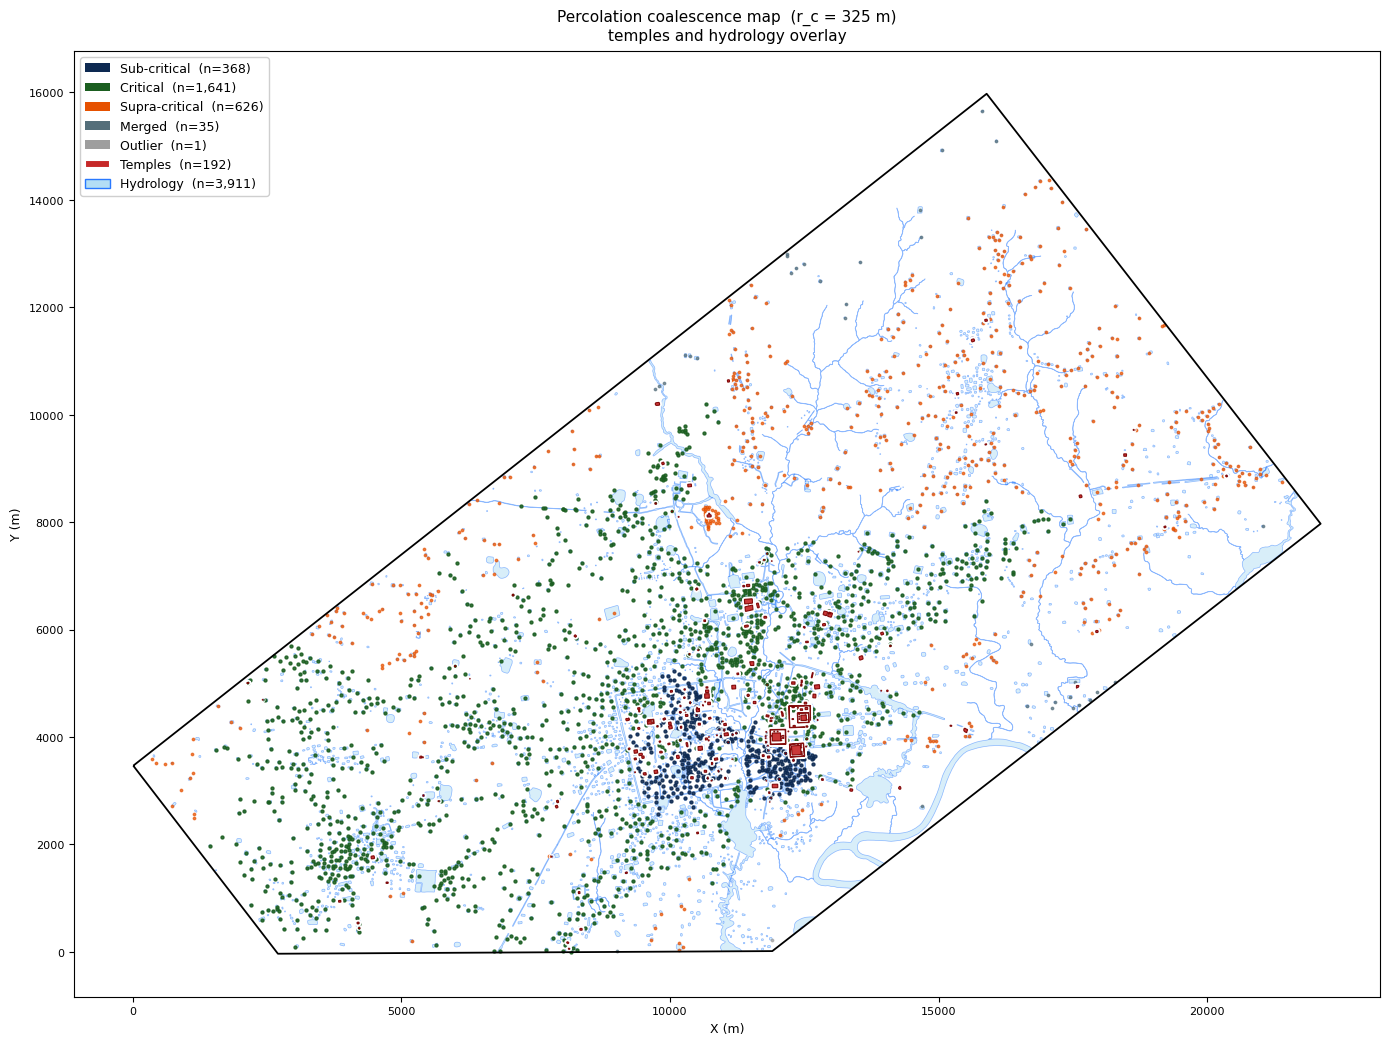

Saved: overlay_percolation_coalescence.png


In [32]:
# Percolation coalescence map
fig, ax = plt.subplots(figsize=(14, 12))

hydrology.plot(ax=ax, facecolor=COL_HYDRO_FILL, edgecolor=COL_HYDRO_EDGE,
               linewidth=0.5, alpha=0.50, zorder=1)

# Plot less dominant stages first so sub-critical is on top
for s in [5, 4, 3, 2, 1]:
    mask = stage == s
    if mask.sum() == 0:
        continue
    ax.scatter(x[mask], y[mask],
               s=4.5 if s <= 2 else 3.0,
               c=STAGE_COL[s],
               alpha=0.88 if s <= 2 else 0.70,
               zorder=2)

plot_temples(ax, zorder=3)
parcel.boundary.plot(ax=ax, color='black', linewidth=1.3, zorder=6)

stage_handles = [
    mpatches.Patch(facecolor=STAGE_COL[s],
                   label=f'{STAGE_NAME[s]}  (n={counts[s]:,})')
    for s in [1, 2, 3, 4, 5] if counts.get(s, 0) > 0
]
extra_handles = [
    mpatches.Patch(facecolor=COL_TEMPLE, edgecolor='white', linewidth=1.5,
                   label=f'Temples  (n={len(temples):,})'),
    mpatches.Patch(facecolor=COL_HYDRO_FILL, edgecolor=COL_HYDRO_EDGE, linewidth=1,
                   label=f'Hydrology  (n={len(hydrology):,})'),
]
ax.legend(handles=stage_handles + extra_handles,
          loc='upper left', fontsize=9, framealpha=0.93)
ax.set_aspect('equal')
ax.set_title(f'Percolation coalescence map  (r_c = {r_c:.0f} m)\n'
             'temples and hydrology overlay', fontsize=11, pad=8)
ax.set_xlabel('X (m)', fontsize=9)
ax.set_ylabel('Y (m)', fontsize=9)
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.savefig(OUT + 'overlay_percolation_coalescence.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: overlay_percolation_coalescence.png')

## 4. Proximity Analysis

Distance from each mound centroid to the nearest temple centroid and the nearest hydrology
polygon boundary, compared across cluster membership for all four methods.

In [33]:
# Temple distances
temple_kd      = cKDTree(np.column_stack([tx, ty]))
dist_temple, _ = temple_kd.query(coords, k=1)

# Hydrology boundary distances (sample boundary coords every 5th vertex)
hydro_pts = []
for geom in hydrology.geometry:
    if geom is None or geom.is_empty: continue
    try:
        hydro_pts.extend(list(geom.exterior.coords)[::5])
    except AttributeError:
        for part in geom.geoms:
            try: hydro_pts.extend(list(part.exterior.coords)[::5])
            except: pass
hydro_kd       = cKDTree(np.array(hydro_pts))
dist_hydro, _  = hydro_kd.query(coords, k=1)

print(f'Temple:   median={np.median(dist_temple):.0f}m, mean={np.mean(dist_temple):.0f}m')
print(f'Hydrology: median={np.median(dist_hydro):.0f}m, mean={np.mean(dist_hydro):.0f}m')

Temple:   median=515m, mean=668m
Hydrology: median=20m, mean=32m


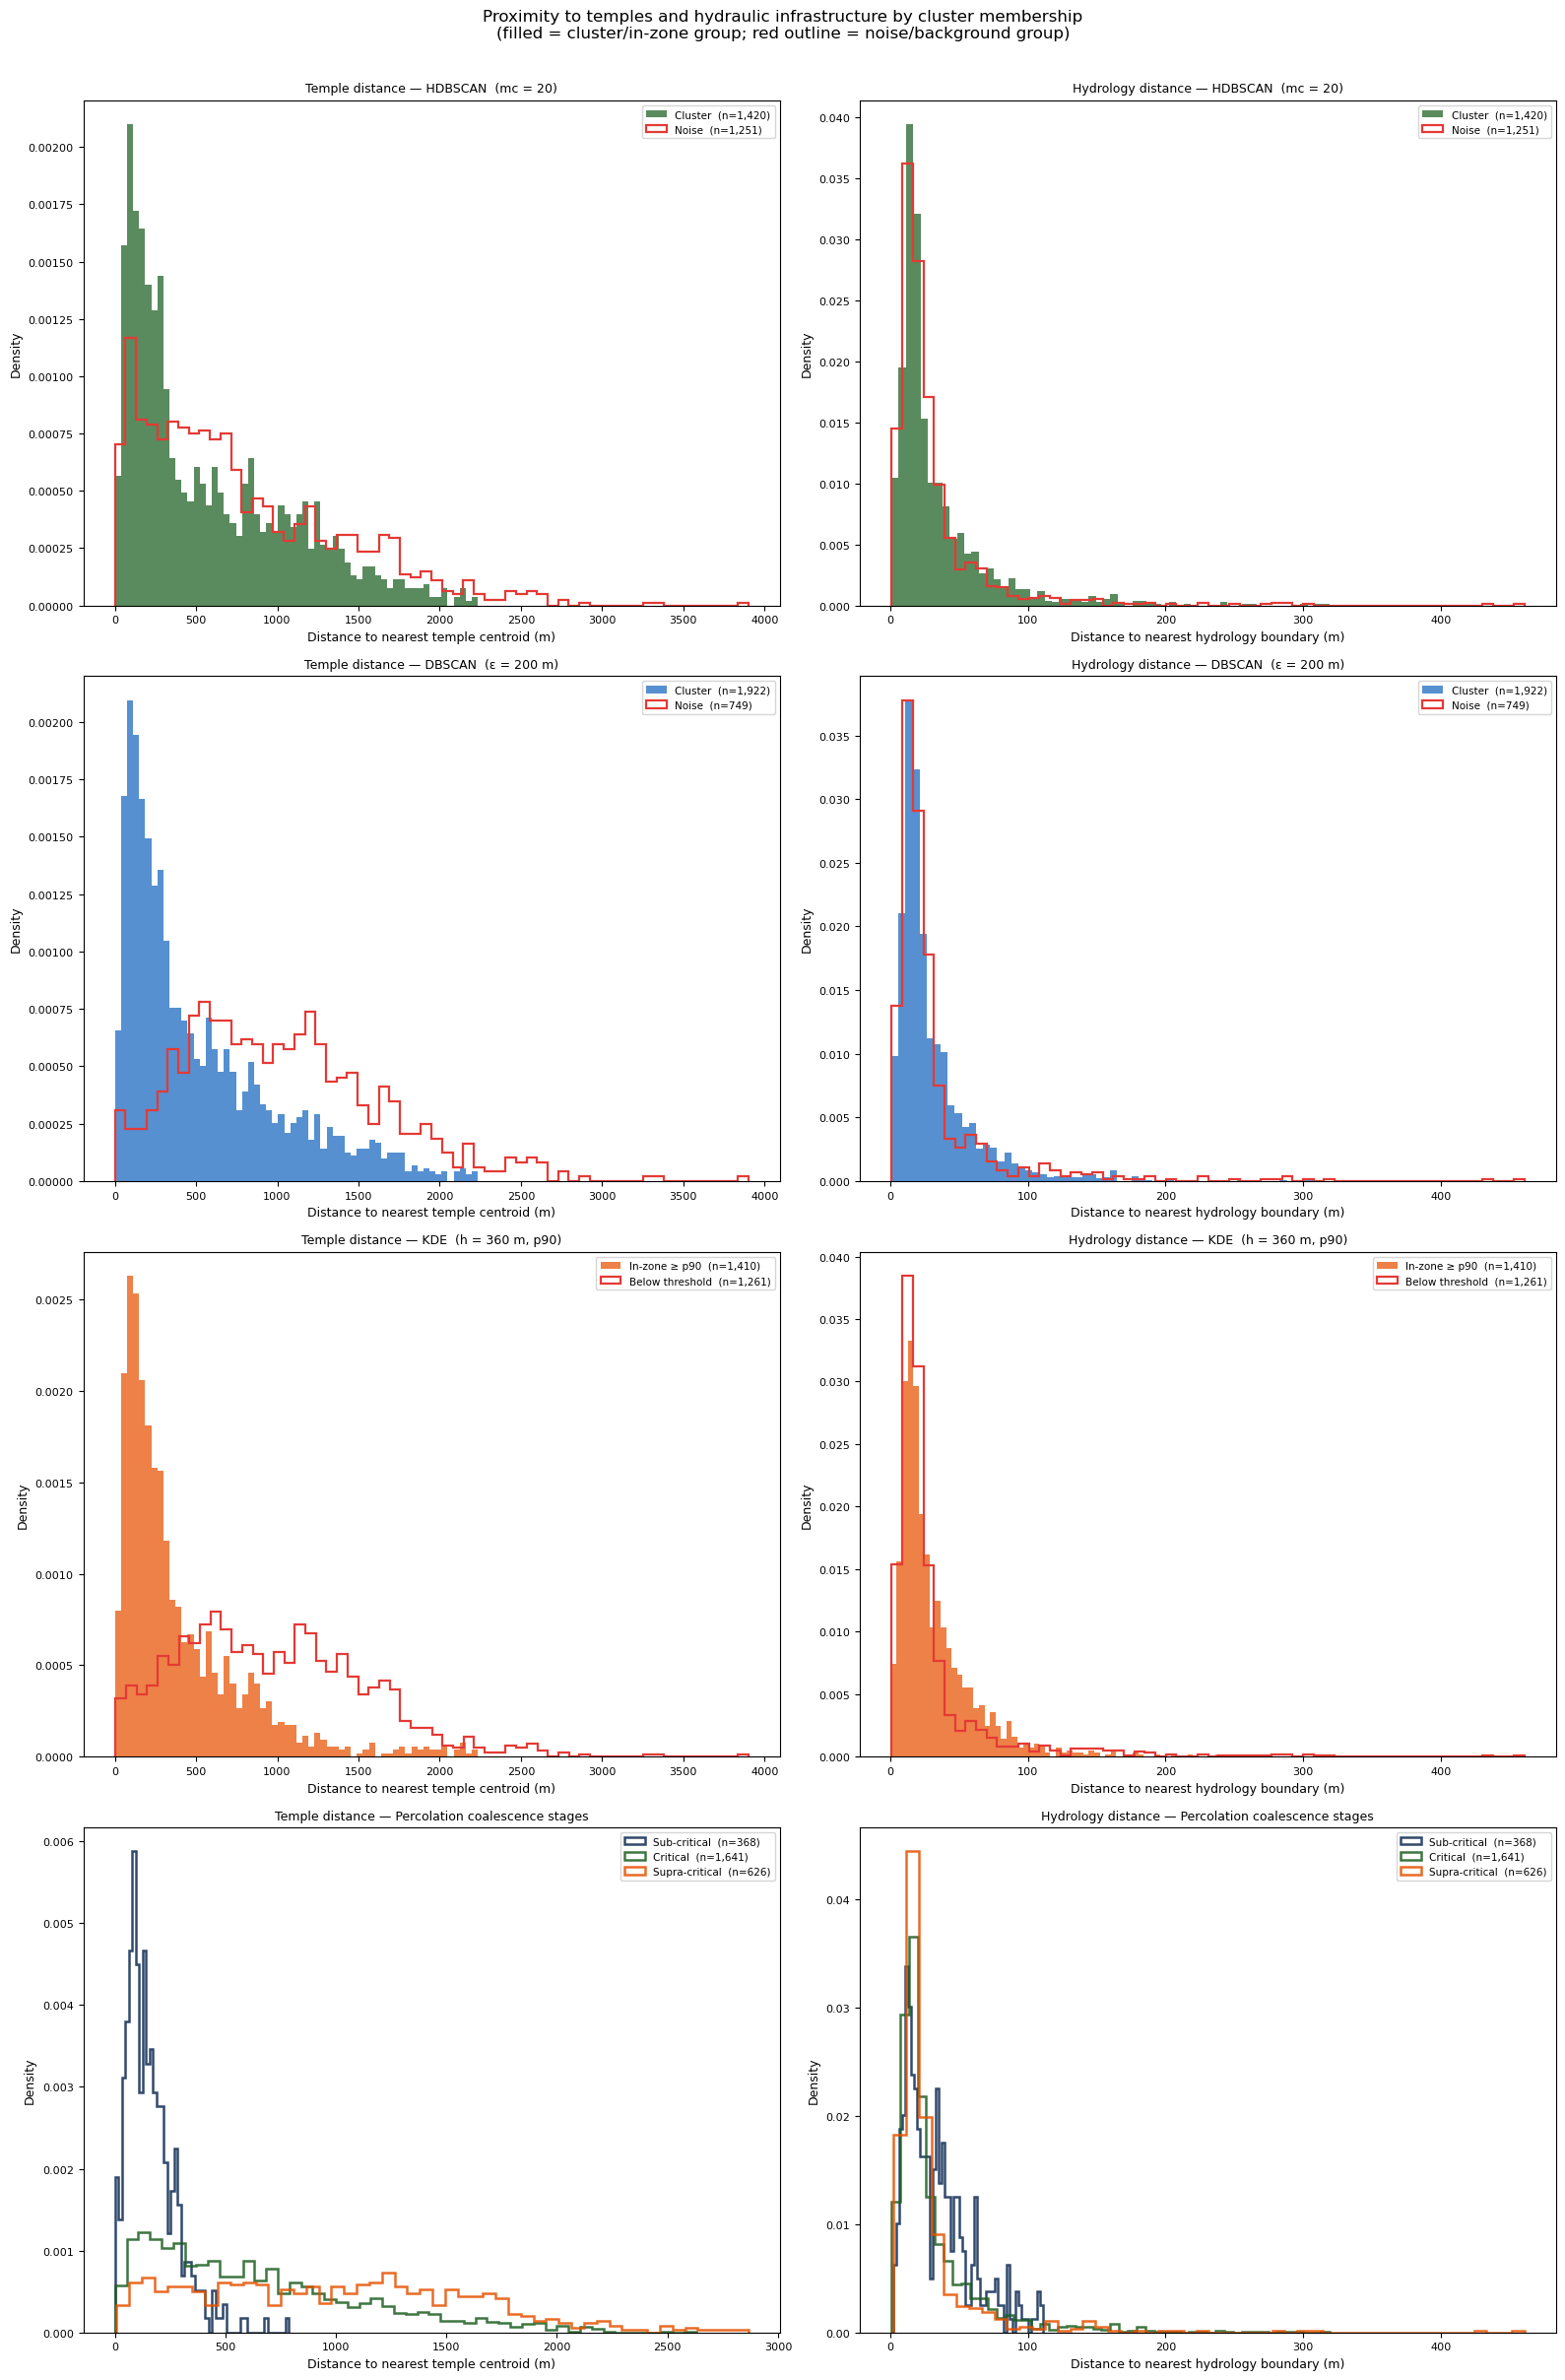

Saved: proximity_analysis_all_methods.png


In [34]:
def dual_hist(ax, dist, m_a, m_b, l_a, l_b, col_a, xlabel, title, bins=60):
    '''Filled step for group A; red step-outline for group B (noise/background).'''
    ax.hist(dist[m_a], bins=bins, color=col_a, alpha=0.72, density=True,
            histtype='stepfilled', label=l_a)
    ax.hist(dist[m_b], bins=bins, color='#E53935', linewidth=1.6,
            density=True, histtype='step', label=l_b)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel('Density', fontsize=9)
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=7.5)
    ax.tick_params(labelsize=8)

hdb_cl = hdb_labels != -1;  hdb_no = hdb_labels == -1
db_cl  = db_labels  != -1;  db_no  = db_labels  == -1
kde_in = kde_inzone;        kde_out = ~kde_inzone

fig, axes = plt.subplots(4, 2, figsize=(16, 24))

# Row 0: HDBSCAN mc=20
dual_hist(axes[0,0], dist_temple, hdb_cl, hdb_no,
          f'Cluster  (n={hdb_cl.sum():,})', f'Noise  (n={hdb_no.sum():,})',
          '#1B5E20', 'Distance to nearest temple centroid (m)',
          'Temple distance — HDBSCAN  (mc = 20)')
dual_hist(axes[0,1], dist_hydro, hdb_cl, hdb_no,
          f'Cluster  (n={hdb_cl.sum():,})', f'Noise  (n={hdb_no.sum():,})',
          '#1B5E20', 'Distance to nearest hydrology boundary (m)',
          'Hydrology distance — HDBSCAN  (mc = 20)')

# Row 1: DBSCAN eps=200m
dual_hist(axes[1,0], dist_temple, db_cl, db_no,
          f'Cluster  (n={db_cl.sum():,})', f'Noise  (n={db_no.sum():,})',
          '#1565C0', 'Distance to nearest temple centroid (m)',
          'Temple distance — DBSCAN  (ε = 200 m)')
dual_hist(axes[1,1], dist_hydro, db_cl, db_no,
          f'Cluster  (n={db_cl.sum():,})', f'Noise  (n={db_no.sum():,})',
          '#1565C0', 'Distance to nearest hydrology boundary (m)',
          'Hydrology distance — DBSCAN  (ε = 200 m)')

# Row 2: KDE h=360m p90
dual_hist(axes[2,0], dist_temple, kde_in, kde_out,
          f'In-zone ≥ p90  (n={kde_in.sum():,})',
          f'Below threshold  (n={kde_out.sum():,})',
          '#E65100', 'Distance to nearest temple centroid (m)',
          'Temple distance — KDE  (h = 360 m, p90)')
dual_hist(axes[2,1], dist_hydro, kde_in, kde_out,
          f'In-zone ≥ p90  (n={kde_in.sum():,})',
          f'Below threshold  (n={kde_out.sum():,})',
          '#E65100', 'Distance to nearest hydrology boundary (m)',
          'Hydrology distance — KDE  (h = 360 m, p90)')

# Row 3: Percolation stages
for ax, dist, xlabel, sfx in [
        (axes[3,0], dist_temple,
         'Distance to nearest temple centroid (m)',    'Temple distance'),
        (axes[3,1], dist_hydro,
         'Distance to nearest hydrology boundary (m)', 'Hydrology distance')]:
    for s in [1, 2, 3, 5]:
        mask = stage == s
        if mask.sum() > 10:
            ax.hist(dist[mask], bins=50, color=STAGE_COL[s], alpha=0.85,
                    density=True, histtype='step', linewidth=1.8,
                    label=f'{STAGE_NAME[s]}  (n={mask.sum():,})')
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel('Density', fontsize=9)
    ax.set_title(f'{sfx} — Percolation coalescence stages', fontsize=9)
    ax.legend(fontsize=7.5)
    ax.tick_params(labelsize=8)

plt.suptitle('Proximity to temples and hydraulic infrastructure by cluster membership\n'
             '(filled = cluster/in-zone group; red outline = noise/background group)',
             fontsize=12, y=1.005)
plt.tight_layout()
plt.savefig(OUT + 'proximity_analysis_all_methods.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: proximity_analysis_all_methods.png')

## 5. Summary Proximity Statistics

In [35]:
groups = [
    ('All mounds',                  np.ones(N, bool)),
    ('HDBSCAN cluster  (mc=20)',    hdb_cl),
    ('HDBSCAN noise  (mc=20)',      hdb_no),
    ('DBSCAN cluster  (ε=200m)',    db_cl),
    ('DBSCAN noise  (ε=200m)',      db_no),
    ('KDE in-zone  (h=360m, p95)',  kde_in),
    ('KDE below threshold',         kde_out),
    ('Percolation: Sub-critical',   stage == 1),
    ('Percolation: Critical',       stage == 2),
    ('Percolation: Supra-critical', stage == 3),
    ('Percolation: Merged',         stage == 4),
]

rows = []
for name, mask in groups:
    dt = dist_temple[mask]; dh = dist_hydro[mask]
    rows.append({'Group': name, 'n': int(mask.sum()),
                 'Temple median (m)': int(np.median(dt)),
                 'Temple % <500m':  f'{100*(dt<500).mean():.1f}%',
                 'Hydro median (m)': int(np.median(dh)),
                 'Hydro % <200m':   f'{100*(dh<200).mean():.1f}%'})

df_prox = pd.DataFrame(rows)
print(df_prox.to_string(index=False))

                      Group    n  Temple median (m) Temple % <500m  Hydro median (m) Hydro % <200m
                 All mounds 2671                514          48.9%                19         99.2%
   HDBSCAN cluster  (mc=20) 1420                384          55.7%                20         99.3%
     HDBSCAN noise  (mc=20) 1251                621          41.2%                19         99.0%
   DBSCAN cluster  (ε=200m) 1922                349          60.6%                20         99.5%
     DBSCAN noise  (ε=200m)  749                969          19.0%                19         98.4%
 KDE in-zone  (h=360m, p95) 1410                258          72.6%                22         99.8%
        KDE below threshold 1261                910          22.5%                18         98.5%
  Percolation: Sub-critical  368                135          98.6%                27        100.0%
      Percolation: Critical 1641                535          47.5%                19         99.1%
Percolatio

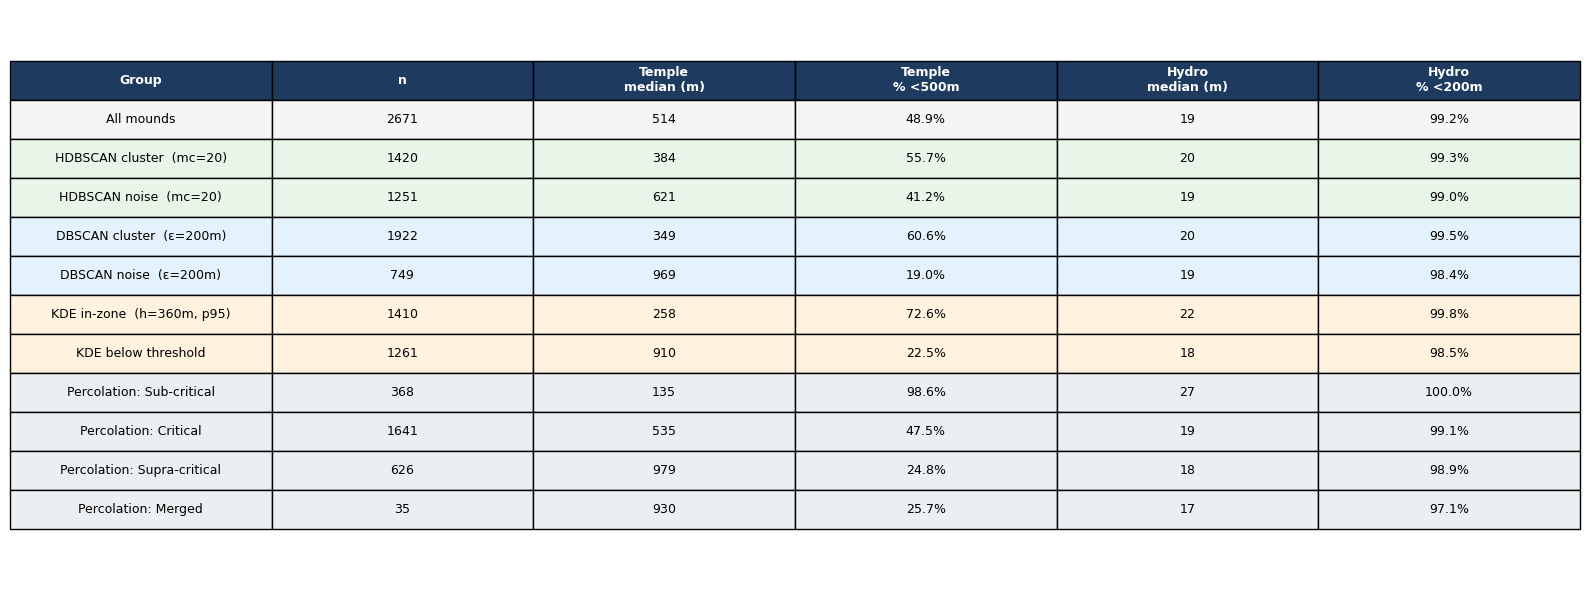

Saved: proximity_summary_table.png


In [36]:
col_labels = ['Group', 'n', 'Temple\nmedian (m)', 'Temple\n% <500m',
              'Hydro\nmedian (m)', 'Hydro\n% <200m']
cell_text = [[r['Group'], str(r['n']),
              str(r['Temple median (m)']), r['Temple % <500m'],
              str(r['Hydro median (m)']), r['Hydro % <200m']]
             for r in rows]

METHOD_COL = {
    'All':          '#F5F5F5',
    'HDBSCAN':      '#E8F5E9',
    'DBSCAN':       '#E3F2FD',
    'KDE':          '#FFF3E0',
    'Percolation':  '#ECEFF1',
}
def row_bg(name):
    for k, v in METHOD_COL.items():
        if name.startswith(k): return v
    return 'white'

fig, ax = plt.subplots(figsize=(16, 6))
ax.axis('off')
tbl = ax.table(cellText=cell_text, colLabels=col_labels,
               loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1, 1.9)

for j in range(len(col_labels)):
    tbl[(0,j)].set_facecolor('#1E3A5F')
    tbl[(0,j)].set_text_props(color='white', fontweight='bold')
for i, r in enumerate(rows, start=1):
    col = row_bg(r['Group'])
    for j in range(len(col_labels)):
        tbl[(i,j)].set_facecolor(col)

plt.tight_layout()
plt.savefig(OUT + 'proximity_summary_table.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: proximity_summary_table.png')